# Sentinel-2 Road Spectral Analysis — Ghana 2017–2023

Consolidates preliminary, temporal, and multi-year analyses into one clean notebook.

**Structure**
1. Setup & Data Loading
2. Baseline Spectral Characterisation (2017–2023 pooled)
3. Seasonal Patterns
4. Year-on-Year Trends
5. Road-Level Temporal Features
6. Regional Analysis


## 1  Setup & Data Loading

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as sp_stats

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

def find_repo_root(start=None, repo_name="Sentinel-FYP"):
    start = (Path(start) if start else Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if p.name == repo_name:
            return p
    raise FileNotFoundError(f"Repo root {repo_name!r} not found from {start}")

ROOT       = find_repo_root()
DATA_DIR   = ROOT / "data"
PAR_ROOT   = DATA_DIR / "ghana_parquet"
REGION_CSV = DATA_DIR / "roads_region_lookup.csv"

IDX_COLS     = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
LOAD_COLS    = ["osm_id", "fclass", "quarter"] + IDX_COLS
KEEP_CLASSES = ["residential", "service", "primary", "secondary",
                "tertiary", "trunk", "unclassified"]
CLASS_ORDER  = ["trunk", "primary", "secondary", "tertiary",
                "residential", "service", "unclassified"]
YEARS        = list(range(2017, 2024))
QMAP         = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}

# Friendly display labels for quarters
QLABELS = {1: "Q1\n(Jan–Mar)", 2: "Q2\n(Apr–Jun)",
           3: "Q3\n(Jul–Sep)", 4: "Q4\n(Oct–Dec)"}

print("Repo root :", ROOT)
print("Parquet   :", PAR_ROOT, "— exists:", PAR_ROOT.exists())


Repo root : /Users/miranda/Documents/GitHub/Sentinel-FYP
Parquet   : /Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana_parquet — exists: True


In [2]:
# Load all year partitions (2017–2023)
frames = []
for ydir in sorted(PAR_ROOT.glob("year=*")):
    year = int(ydir.name.split("=")[1])
    if year not in YEARS:
        continue
    parquet_files = sorted(ydir.glob("*.parquet"))
    if not parquet_files:
        print(f"  Warning: no parquet files in {ydir.name}")
        continue
    df_y = pd.read_parquet(parquet_files[0], columns=LOAD_COLS)
    df_y["year"] = year
    frames.append(df_y)
    print(f"  {ydir.name}: {len(df_y):,} rows")

raw = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows: {len(raw):,}")
print("Years    :", sorted(raw["year"].unique()))


  year=2017: 658,208 rows
  year=2018: 987,312 rows
  year=2019: 1,316,416 rows
  year=2020: 1,316,416 rows
  year=2021: 1,316,416 rows
  year=2022: 1,316,416 rows
  year=2023: 1,316,416 rows

Total rows: 8,227,600
Years    : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [3]:
# ── Clean and standardise ────────────────────────────────────────────────────
raw["fclass"]  = raw["fclass"].astype(str).str.strip().str.lower()
raw["quarter"] = raw["quarter"].astype(str).str.strip().str.upper()

# Class filter
raw = raw[raw["fclass"].isin(KEEP_CLASSES)].copy()

# Quarter → integer
raw["qnum"] = raw["quarter"].map(QMAP)
raw = raw.dropna(subset=["qnum"]).copy()
raw["qnum"] = raw["qnum"].astype(int)

# Convert to numeric
for c in IDX_COLS:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

rows_before = len(raw)

# Remove NaN
raw = raw.dropna(subset=IDX_COLS).copy()

# Remove out-of-range
in_range = np.logical_and.reduce([(raw[c] >= -1) & (raw[c] <= 1) for c in IDX_COLS])
raw = raw[in_range].copy()

# Remove all-zero rows (sensor no-data artefacts)
zero_mask = (raw[IDX_COLS] == 0).any(axis=1)
raw = raw[~zero_mask].copy()

rows_after = len(raw)
pct_removed = 100 * (rows_before - rows_after) / rows_before

print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after cleaning  : {rows_after:,}  ({pct_removed:.1f}% removed)")
print("Classes  :", sorted(raw["fclass"].unique()))
print("Years    :", sorted(raw["year"].unique()))
print("Quarters :", sorted(raw["quarter"].unique()))

raw["osm_id"] = raw["osm_id"].astype(str)
df = raw.copy()
del raw


Rows before cleaning : 8,227,600
Rows after cleaning  : 6,375,404  (22.5% removed)
Classes  : ['primary', 'residential', 'secondary', 'service', 'tertiary', 'trunk', 'unclassified']
Years    : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Quarters : ['Q1', 'Q2', 'Q3', 'Q4']


In [4]:
# ── Data completeness — unique roads per year and class ──────────────────────
completeness = (
    df.groupby(["year", "fclass"])["osm_id"]
    .nunique()
    .unstack("fclass")
    .reindex(columns=CLASS_ORDER)
    .fillna(0)
    .astype(int)
)
completeness.index.name = "year"
print("Unique OSM road segments per year × class:")
display(completeness)


Unique OSM road segments per year × class:


fclass,trunk,primary,secondary,tertiary,residential,service,unclassified
year,,,,,,,
2017,1218,1171,1582,2837,125777,24806,14186
2018,1822,1597,2397,4755,257398,35627,22950
2019,1822,1597,2397,4755,257398,35627,22950
2020,1822,1597,2397,4755,257398,35627,22950
2021,1822,1597,2397,4755,257398,35627,22950
2022,1822,1597,2397,4755,257398,35627,22950
2023,1822,1597,2397,4755,257398,35627,22950


## 2  Baseline Spectral Characterisation (2017–2023 Pooled)

Summary statistics and distributions of the five Sentinel-2 spectral indices
across the seven OSM road classes, computed from all available imagery 2017–2023.


In [5]:
# Descriptive statistics (mean ± std, median, IQR) per class
def iqr_fn(x):
    return x.quantile(0.75) - x.quantile(0.25)

stats_tbl = (
    df.groupby("fclass")[IDX_COLS]
    .agg(["mean", "std", "median", iqr_fn])
    .reindex(CLASS_ORDER)
)
# Flatten multi-level columns
stats_tbl.columns = ["_".join(c) for c in stats_tbl.columns]
stats_tbl.index.name = "road_class"

# Compact mean ± std view
compact = pd.DataFrame(index=CLASS_ORDER)
for c in IDX_COLS:
    m = df.groupby("fclass")[c].mean().reindex(CLASS_ORDER)
    s = df.groupby("fclass")[c].std().reindex(CLASS_ORDER)
    compact[c] = m.map("{:.3f}".format) + " ± " + s.map("{:.3f}".format)
compact.index.name = "road_class"

print("Mean ± Std — all years pooled (2017–2023)")
display(compact)


Mean ± Std — all years pooled (2017–2023)


,NDVI,NDMI,NDBI,NDWI,BSI
road_class,,,,,
trunk,0.191 ± 0.131,-0.074 ± 0.090,0.074 ± 0.090,-0.256 ± 0.124,0.106 ± 0.086
primary,0.191 ± 0.143,-0.080 ± 0.093,0.080 ± 0.093,-0.258 ± 0.141,0.111 ± 0.089
secondary,0.197 ± 0.147,-0.077 ± 0.096,0.077 ± 0.096,-0.262 ± 0.140,0.107 ± 0.090
tertiary,0.226 ± 0.161,-0.072 ± 0.104,0.072 ± 0.104,-0.295 ± 0.149,0.106 ± 0.098
residential,0.255 ± 0.138,-0.081 ± 0.089,0.081 ± 0.089,-0.326 ± 0.124,0.116 ± 0.087
service,0.181 ± 0.133,-0.094 ± 0.082,0.094 ± 0.082,-0.250 ± 0.132,0.120 ± 0.080
unclassified,0.361 ± 0.179,-0.027 ± 0.128,0.027 ± 0.128,-0.412 ± 0.138,0.070 ± 0.125


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_21075/3669790796.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_21075/3669790796.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_ORDER, rotation=40, ha="right", fontsize=8)
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_21075/3669790796.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_21075/3669790796.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ti

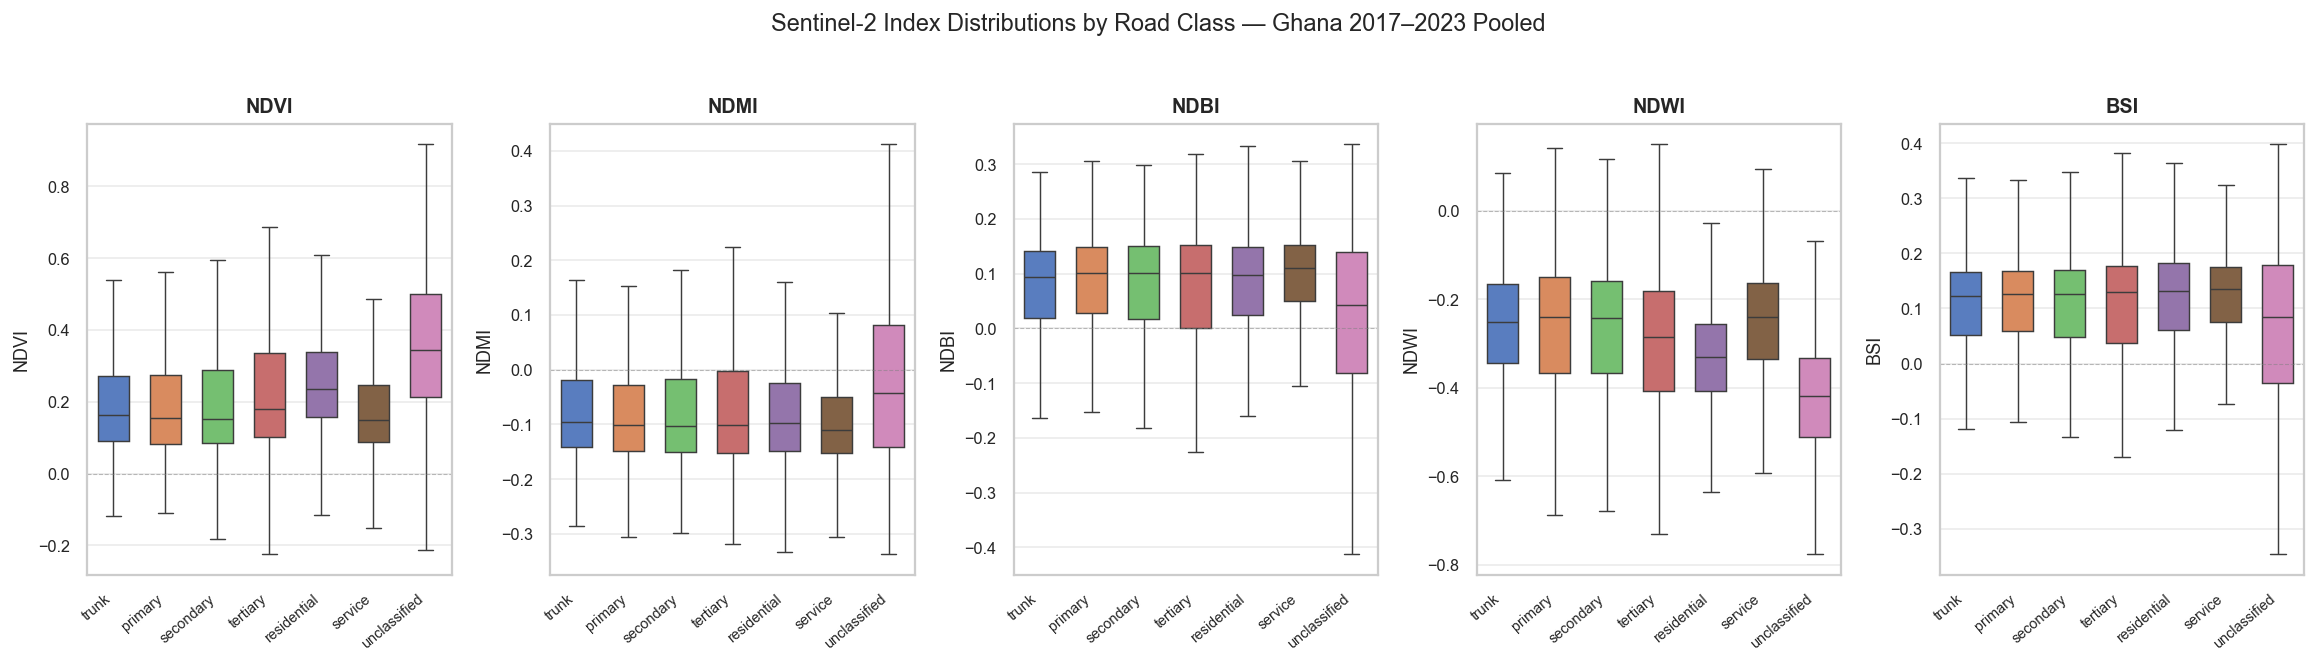

In [6]:
# ── Figure 1: Spectral index distributions by road class ─────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
palette = sns.color_palette("muted", n_colors=len(CLASS_ORDER))

plot_df = df.copy()
plot_df["fclass"] = pd.Categorical(plot_df["fclass"], categories=CLASS_ORDER, ordered=True)

for ax, c in zip(axes, IDX_COLS):
    sns.boxplot(
        data=plot_df, x="fclass", y=c, order=CLASS_ORDER,
        showfliers=False, palette=palette, ax=ax, linewidth=0.8,
        width=0.6,
    )
    ax.set_xlabel("")
    ax.set_ylabel(c, fontsize=10)
    ax.set_title(c, fontsize=11, fontweight="bold")
    ax.set_xticklabels(CLASS_ORDER, rotation=40, ha="right", fontsize=8)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--", alpha=0.5)
    ax.grid(axis="y", alpha=0.35)

fig.suptitle(
    "Sentinel-2 Index Distributions by Road Class — Ghana 2017–2023 Pooled",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()


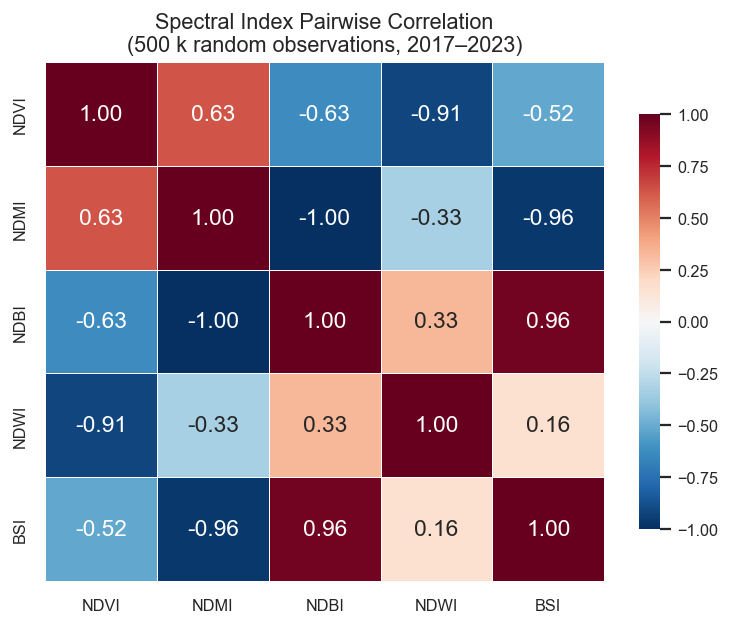


Note: NDBI = −NDWI by construction (same bands, inverted sign).


In [7]:
# ── Figure 2: Index correlation heatmap ──────────────────────────────────────
# Sample for speed if needed; with ~7M rows correlation is stable on a subset
sample = df[IDX_COLS].sample(min(500_000, len(df)), random_state=42)
corr   = sample.corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask    = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle (keep lower)
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
)
ax.set_title("Spectral Index Pairwise Correlation\n(500 k random observations, 2017–2023)")
plt.tight_layout()
plt.show()

print("\nNote: NDBI = −NDWI by construction (same bands, inverted sign).")


## 3  Seasonal Patterns

Quarterly mean index values, pooled across all years 2017–2023, reveal how
surface spectral properties vary with Ghana's bimodal rainy seasons
(March–July and September–November).


In [8]:
# Quarterly means by class (pooled across years)
q_mean = (
    df.groupby(["fclass", "qnum"])[IDX_COLS]
    .mean()
    .reset_index()
)
q_mean["fclass"] = pd.Categorical(q_mean["fclass"], categories=CLASS_ORDER, ordered=True)
q_mean = q_mean.sort_values(["fclass", "qnum"])


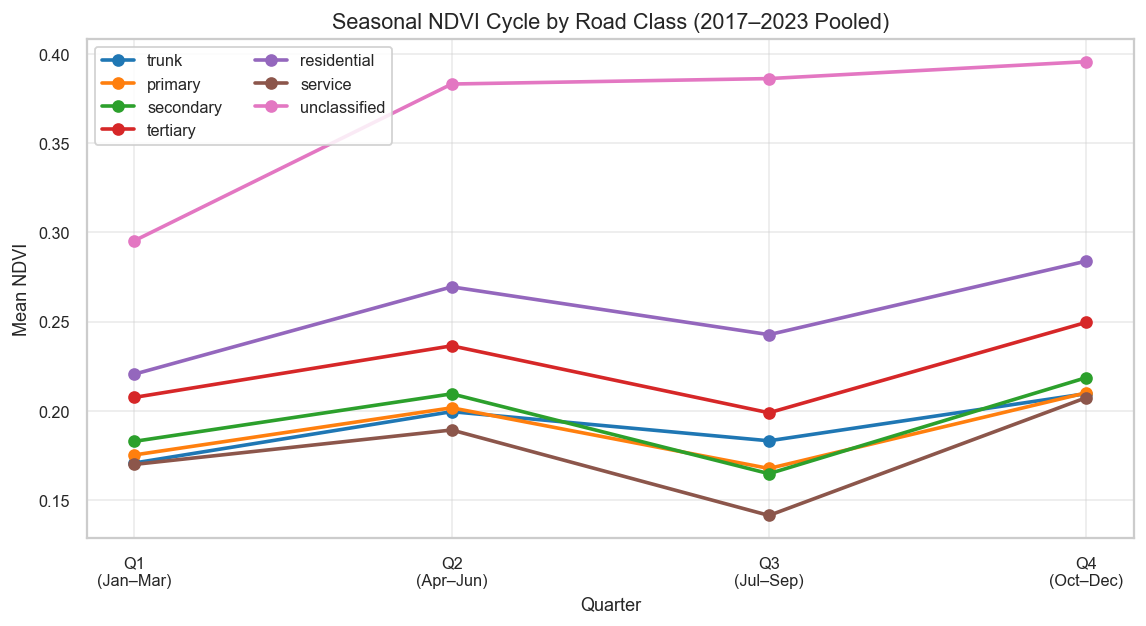

In [9]:
# ── Figure 3: NDVI seasonal cycle by class ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette("tab10", n_colors=len(CLASS_ORDER))

for cls, col in zip(CLASS_ORDER, palette):
    sub = q_mean[q_mean["fclass"] == cls]
    ax.plot(sub["qnum"], sub["NDVI"], marker="o", label=cls, color=col, linewidth=2)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Q1\n(Jan–Mar)", "Q2\n(Apr–Jun)", "Q3\n(Jul–Sep)", "Q4\n(Oct–Dec)"])
ax.set_xlabel("Quarter")
ax.set_ylabel("Mean NDVI")
ax.set_title("Seasonal NDVI Cycle by Road Class (2017–2023 Pooled)")
ax.legend(loc="upper left", ncol=2, framealpha=0.85)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()


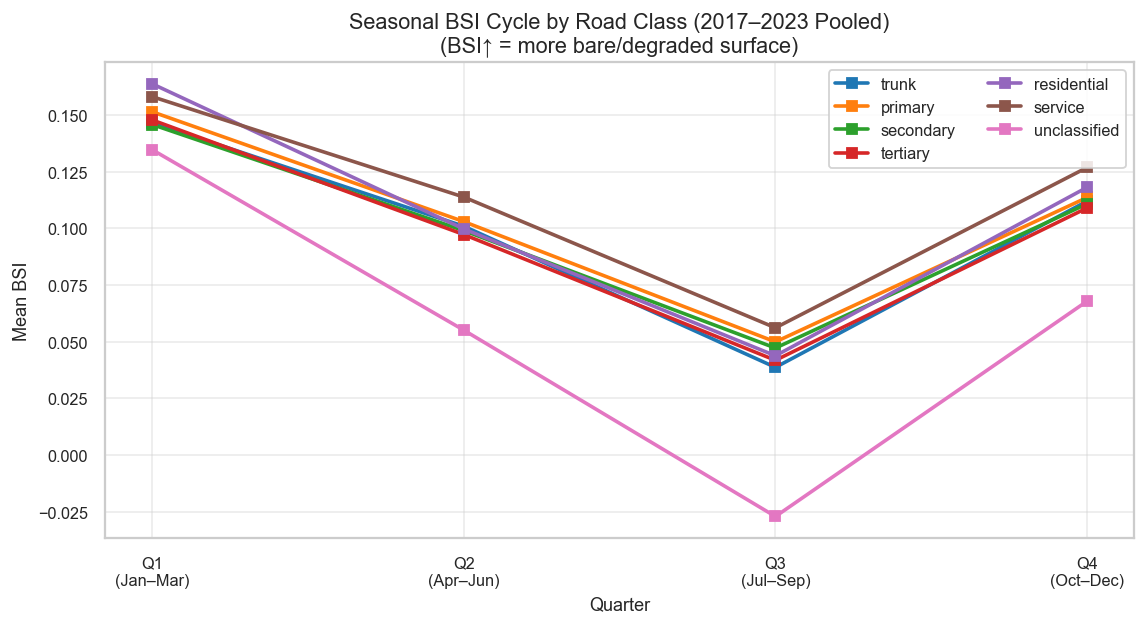

In [10]:
# ── Figure 4: BSI seasonal cycle by class ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for cls, col in zip(CLASS_ORDER, palette):
    sub = q_mean[q_mean["fclass"] == cls]
    ax.plot(sub["qnum"], sub["BSI"], marker="s", label=cls, color=col, linewidth=2)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Q1\n(Jan–Mar)", "Q2\n(Apr–Jun)", "Q3\n(Jul–Sep)", "Q4\n(Oct–Dec)"])
ax.set_xlabel("Quarter")
ax.set_ylabel("Mean BSI")
ax.set_title("Seasonal BSI Cycle by Road Class (2017–2023 Pooled)\n"
             "(BSI↑ = more bare/degraded surface)")
ax.legend(loc="upper right", ncol=2, framealpha=0.85)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_21075/3750293673.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q_mean.groupby("fclass")["NDVI"]


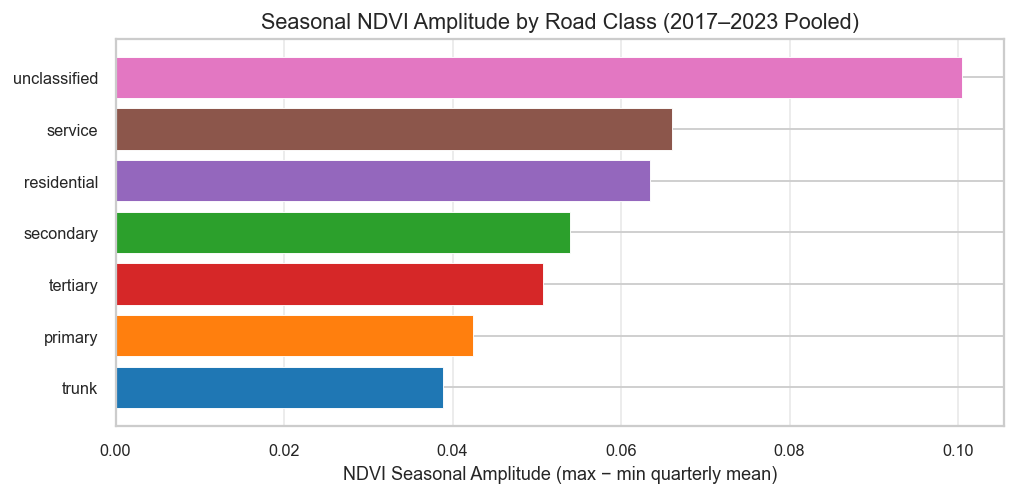


Highest amplitude → strongest seasonal greenness variation.
Unclassified roads (often rural/vegetated surroundings) show largest swing.


In [11]:
# ── Figure 5: Seasonal amplitude (NDVI range Q1–Q3) by class ─────────────────
# Amplitude = max quarterly NDVI minus min quarterly NDVI across Q1–Q4
amp = (
    q_mean.groupby("fclass")["NDVI"]
    .agg(lambda x: x.max() - x.min())
    .reindex(CLASS_ORDER)
    .reset_index()
)
amp.columns = ["fclass", "ndvi_amplitude"]
amp = amp.sort_values("ndvi_amplitude", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [palette[CLASS_ORDER.index(c)] for c in amp["fclass"]]
ax.barh(amp["fclass"], amp["ndvi_amplitude"], color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("NDVI Seasonal Amplitude (max − min quarterly mean)")
ax.set_title("Seasonal NDVI Amplitude by Road Class (2017–2023 Pooled)")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

print("\nHighest amplitude → strongest seasonal greenness variation.")
print("Unclassified roads (often rural/vegetated surroundings) show largest swing.")


## 4  Year-on-Year Trends (2017–2023)

Annual mean spectral values track long-run changes in road-corridor land cover.
YoY deltas highlight years of anomalous change (e.g. drought, sensor artefacts).


In [12]:
# Annual means per class
yearly = (
    df.groupby(["fclass", "year"])[IDX_COLS]
    .mean()
    .reset_index()
    .sort_values(["fclass", "year"])
)
# YoY deltas
for c in IDX_COLS:
    yearly[f"{c}_yoy"] = yearly.groupby("fclass")[c].diff()

yearly["fclass"] = pd.Categorical(yearly["fclass"], categories=CLASS_ORDER, ordered=True)


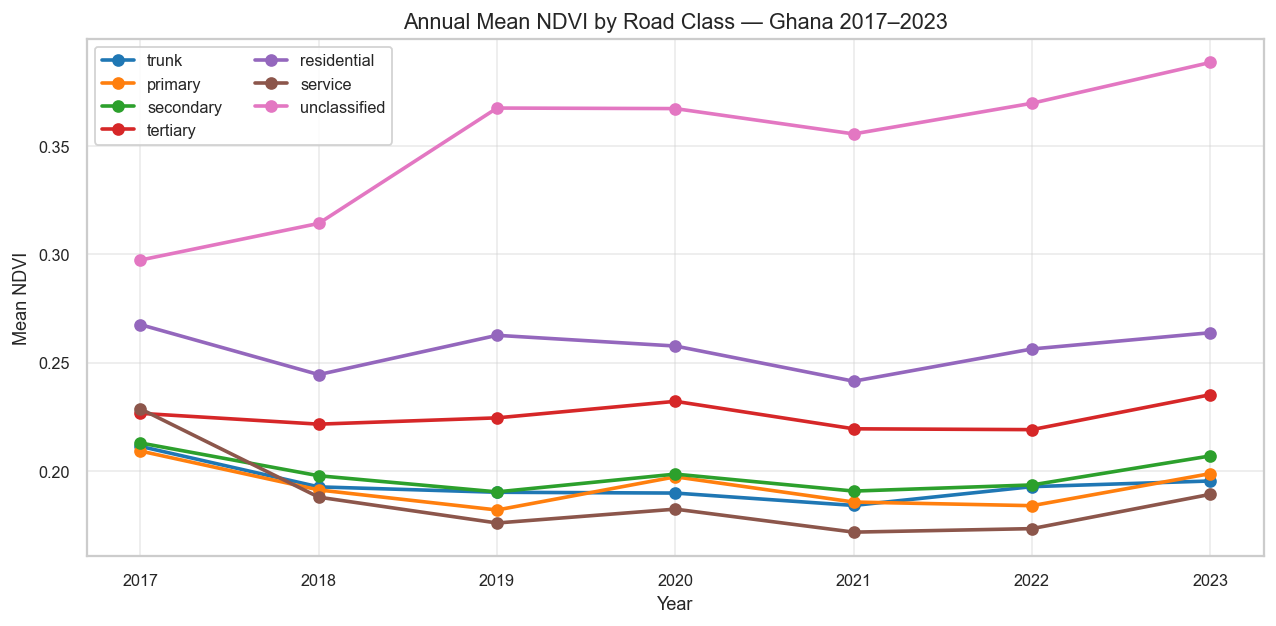

In [13]:
# ── Figure 6: NDVI trend lines 2017–2023 ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for cls, col in zip(CLASS_ORDER, palette):
    sub = yearly[yearly["fclass"] == cls].sort_values("year")
    ax.plot(sub["year"], sub["NDVI"], marker="o", label=cls, color=col, linewidth=2)

ax.set_xticks(YEARS)
ax.set_xlabel("Year")
ax.set_ylabel("Mean NDVI")
ax.set_title("Annual Mean NDVI by Road Class — Ghana 2017–2023")
ax.legend(ncol=2, framealpha=0.85)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()


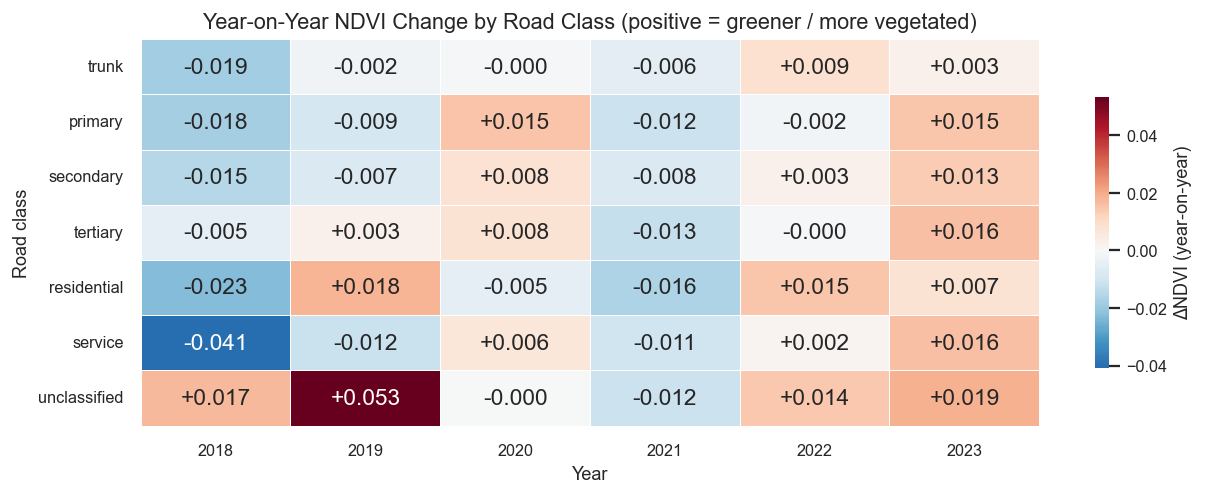

In [14]:
# ── Figure 7: YoY NDVI delta heatmap (class × year) ─────────────────────────
yoy_pivot = (
    yearly.dropna(subset=["NDVI_yoy"])
    .pivot(index="fclass", columns="year", values="NDVI_yoy")
    .reindex(CLASS_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    yoy_pivot, annot=True, fmt="+.3f",
    cmap="RdBu_r", center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "ΔNDVI (year-on-year)", "shrink": 0.7},
)
ax.set_xlabel("Year")
ax.set_ylabel("Road class")
ax.set_title("Year-on-Year NDVI Change by Road Class (positive = greener / more vegetated)")
plt.tight_layout()
plt.show()


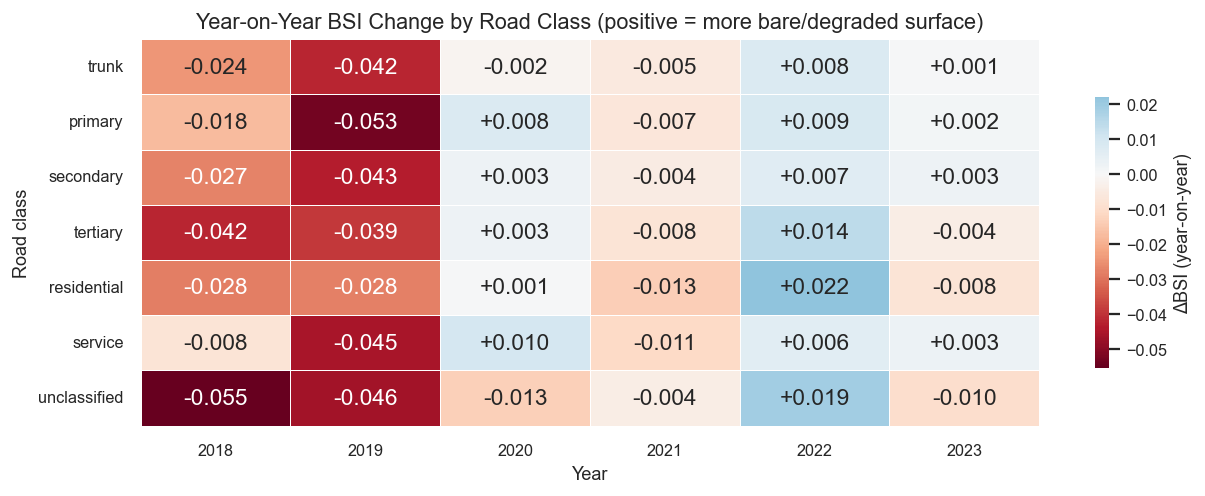

In [15]:
# ── Figure 8: YoY BSI delta heatmap ──────────────────────────────────────────
yoy_bsi_pivot = (
    yearly.dropna(subset=["BSI_yoy"])
    .pivot(index="fclass", columns="year", values="BSI_yoy")
    .reindex(CLASS_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    yoy_bsi_pivot, annot=True, fmt="+.3f",
    cmap="RdBu", center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "ΔBSI (year-on-year)", "shrink": 0.7},
)
ax.set_xlabel("Year")
ax.set_ylabel("Road class")
ax.set_title("Year-on-Year BSI Change by Road Class (positive = more bare/degraded surface)")
plt.tight_layout()
plt.show()


## 5  Road-Level Temporal Features

Per-road linear trends across 2017–2023 capture cumulative spectral change at
the individual road segment level. A negative NDVI slope combined with a
positive BSI slope is used as a proxy for surface degradation (decreasing
vegetation / increasing bare surface exposure).

> **Limitation**: NIRTIMS condition surveys date from November 2025, ~5 years
> after the bulk of the S2 archive used here. Temporal trends should be
> interpreted as indicative signals, not validated ground truth.


In [16]:
# Vectorised OLS slope computation (avoids slow per-group Python loop)
# Uses formula: slope = (n·Σxy − Σx·Σy) / (n·Σx² − (Σx)²)
# where x = time index t = year*4 + qnum

sub = df[["osm_id", "fclass", "year", "qnum", "NDVI", "BSI"]].dropna().copy()
sub["t"]      = sub["year"] * 4 + sub["qnum"]
sub["t_ndvi"] = sub["t"] * sub["NDVI"]
sub["t_bsi"]  = sub["t"] * sub["BSI"]
sub["t2"]     = sub["t"] ** 2

print("Computing per-road aggregates...")
agg = sub.groupby("osm_id").agg(
    fclass   = ("fclass",   "first"),
    n        = ("t",        "count"),
    sum_t    = ("t",        "sum"),
    sum_t2   = ("t2",       "sum"),
    sum_ndvi = ("NDVI",     "sum"),
    sum_bsi  = ("BSI",      "sum"),
    sum_t_n  = ("t_ndvi",   "sum"),
    sum_t_b  = ("t_bsi",    "sum"),
).reset_index()

denom = agg["n"] * agg["sum_t2"] - agg["sum_t"] ** 2
valid = (agg["n"] >= 6) & (denom.abs() > 1e-10)

road_slopes = agg[valid].copy()
road_slopes["ndvi_slope"] = (
    road_slopes["n"] * road_slopes["sum_t_n"] -
    road_slopes["sum_t"] * road_slopes["sum_ndvi"]
) / denom[valid].values

road_slopes["bsi_slope"] = (
    road_slopes["n"] * road_slopes["sum_t_b"] -
    road_slopes["sum_t"] * road_slopes["sum_bsi"]
) / denom[valid].values

road_slopes["fclass"] = pd.Categorical(
    road_slopes["fclass"], categories=CLASS_ORDER, ordered=True
)

print(f"Roads with valid slopes (≥6 obs): {len(road_slopes):,}")
road_slopes[["osm_id", "fclass", "n", "ndvi_slope", "bsi_slope"]].describe()


Computing per-road aggregates...
Roads with valid slopes (≥6 obs): 326,546


,n,ndvi_slope,bsi_slope
count,326546.0000,326546.0000,326546.0000
mean,19.5238,0.0007,-0.0010
std,2.7001,0.0035,0.0027
min,10.0000,-0.0335,-0.0174
25%,17.0000,-0.0015,-0.0028
50%,20.0000,0.0004,-0.0013
75%,22.0000,0.0028,0.0004
max,25.0000,0.0244,0.0230


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_21075/769617159.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_21075/769617159.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_ORDER, rotation=35, ha="right")
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_21075/769617159.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_21075/769617159.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e

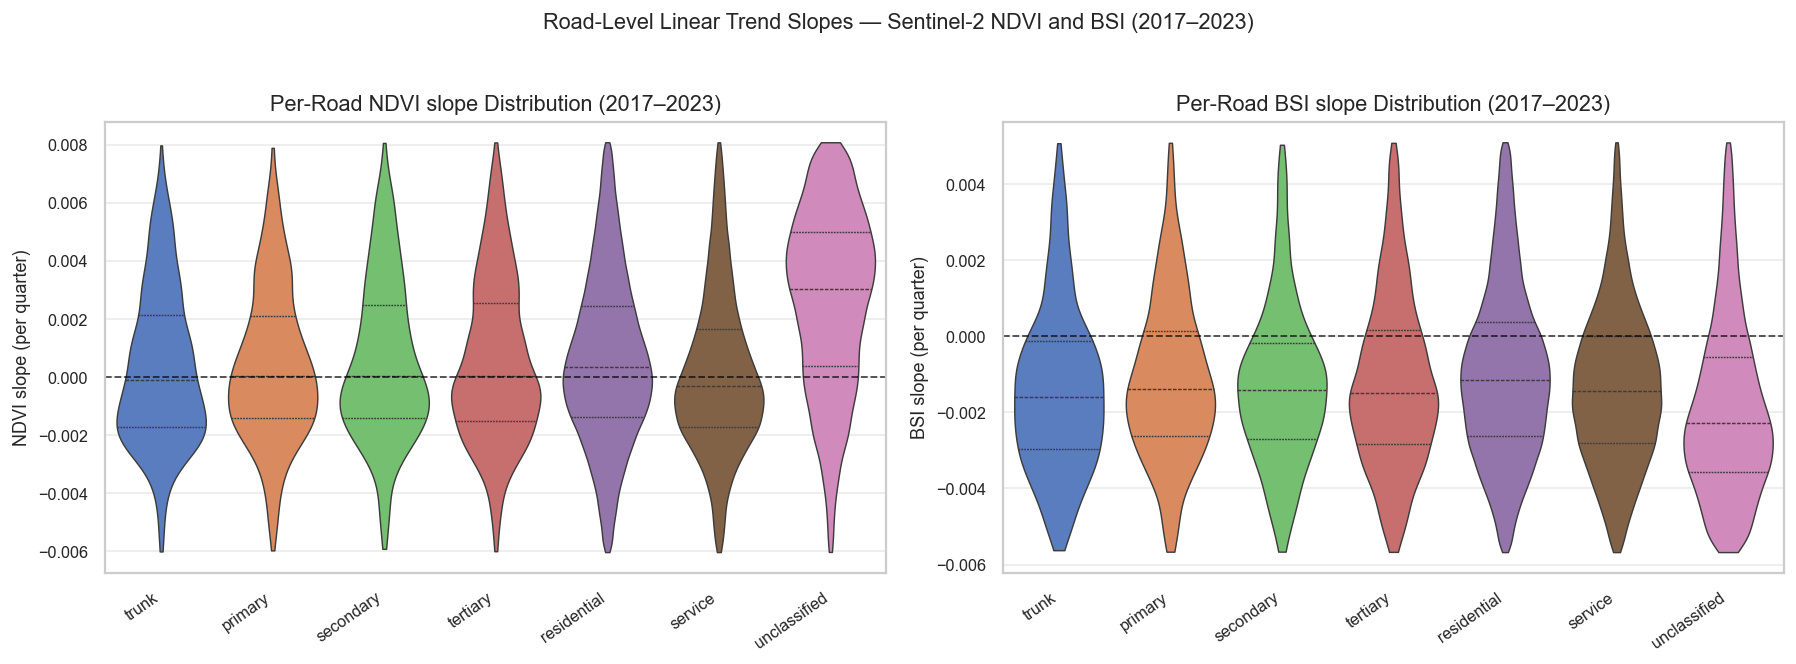

In [17]:
# ── Figure 9: Violin plots — NDVI and BSI slope by class ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, color_base in [
    (axes[0], "ndvi_slope", "NDVI slope (per quarter)", "Blues"),
    (axes[1], "bsi_slope",  "BSI slope (per quarter)",  "Oranges"),
]:
    # clip extreme outliers for legibility (≥2.5th, ≤97.5th percentile)
    lo, hi = road_slopes[col].quantile([0.025, 0.975])
    plot_rs = road_slopes[(road_slopes[col] >= lo) & (road_slopes[col] <= hi)]

    sns.violinplot(
        data=plot_rs, x="fclass", y=col, order=CLASS_ORDER,
        palette="muted", inner="quartile", ax=ax, linewidth=0.8, cut=0,
    )
    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_title(f"Per-Road {label.split('(')[0].strip()} Distribution (2017–2023)")
    ax.set_xticklabels(CLASS_ORDER, rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.35)

fig.suptitle("Road-Level Linear Trend Slopes — Sentinel-2 NDVI and BSI (2017–2023)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [18]:
# ── Degradation flag: NDVI slope < 0 AND BSI slope > 0 ──────────────────────
road_slopes["deg_flag"] = (
    (road_slopes["ndvi_slope"] < 0) & (road_slopes["bsi_slope"] > 0)
).astype(int)

# Class-wise degradation summary
risk = (
    road_slopes.groupby("fclass")
    .agg(
        total_roads  = ("osm_id",    "count"),
        flagged_roads = ("deg_flag",  "sum"),
    )
    .reindex(CLASS_ORDER)
)
risk["deg_pct"] = 100 * risk["flagged_roads"] / risk["total_roads"]
risk.index.name = "road_class"
print("Roads flagged as potentially degrading (NDVI↓ & BSI↑ over 2017–2023):")
display(risk.round(1))


Roads flagged as potentially degrading (NDVI↓ & BSI↑ over 2017–2023):


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_21075/3439654470.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  road_slopes.groupby("fclass")


,total_roads,flagged_roads,deg_pct
road_class,,,
trunk,1822,266,14.6000
primary,1597,279,17.5000
secondary,2397,334,13.9000
tertiary,4755,749,15.8000
residential,257398,46881,18.2000
service,35627,5225,14.7000
unclassified,22950,2151,9.4000


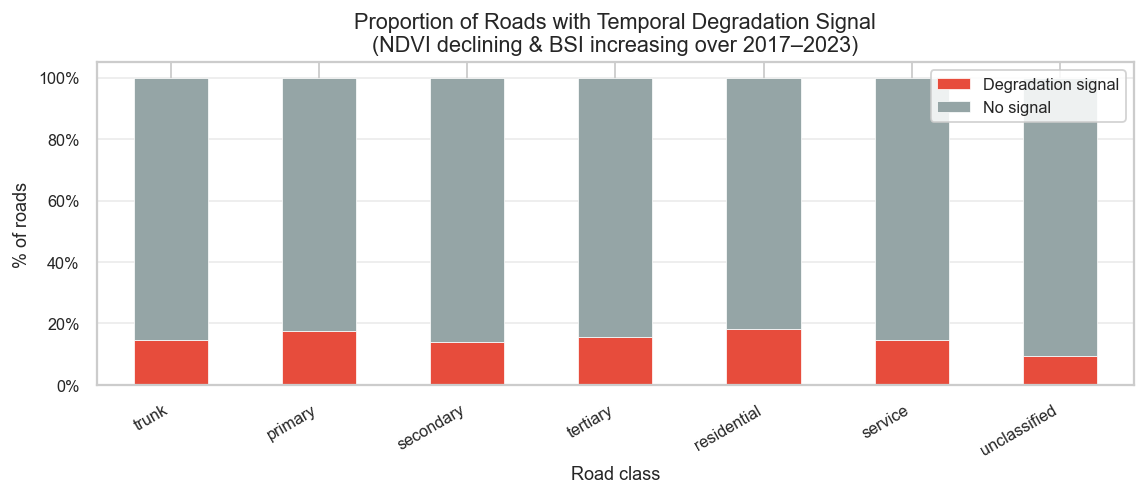

In [19]:
# ── Figure 10: Degradation risk by class (stacked bar) ───────────────────────
risk_plot = risk[["flagged_roads", "total_roads"]].copy()
risk_plot["stable_roads"] = risk_plot["total_roads"] - risk_plot["flagged_roads"]

# Percentage stacked bar
pct = pd.DataFrame({
    "Degradation signal": risk["deg_pct"],
    "No signal":          100 - risk["deg_pct"],
}, index=CLASS_ORDER).reindex(CLASS_ORDER)

fig, ax = plt.subplots(figsize=(9, 4))
pct.plot(
    kind="bar", stacked=True, ax=ax,
    color=["#e74c3c", "#95a5a6"], edgecolor="white", linewidth=0.4,
)
ax.set_xlabel("Road class")
ax.set_ylabel("% of roads")
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_title("Proportion of Roads with Temporal Degradation Signal\n"
             "(NDVI declining & BSI increasing over 2017–2023)")
ax.legend(loc="upper right", framealpha=0.85)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


## 6  Regional Analysis

Merges the OSM road segments with the Ghana administrative region lookup
(`data/roads_region_lookup.csv`) to examine spatial patterns in spectral
indices and road composition across regions.


In [20]:
# Load region lookup
lookup = pd.read_csv(REGION_CSV)
print("Lookup columns:", lookup.columns.tolist())
print("Sample:", lookup.head(3).to_string())


Lookup columns: ['system:index', 'osm_id', 'region', '.geo']
Sample:            system:index     osm_id      region                                    .geo
0  000000000000000000e2  520162721       Ahafo  {"type":"MultiPoint","coordinates":[]}
1  00000000000000000333  574240962  Upper West  {"type":"MultiPoint","coordinates":[]}
2  00000000000000000336  574240965  Upper West  {"type":"MultiPoint","coordinates":[]}


In [21]:
# Merge region onto df
# Normalise osm_id to string on both sides
lookup["osm_id"] = lookup["osm_id"].astype(str)

# Use 2023 snapshot for region composition (latest year)
df_2023 = df[df["year"] == 2023].copy()

df_reg = df_2023.merge(
    lookup[["osm_id", "region"]].drop_duplicates("osm_id"),
    on="osm_id", how="left",
)
match_pct = 100 * df_reg["region"].notna().mean()
print(f"Region match: {match_pct:.1f}% of 2023 road observations")
print("Regions found:", sorted(df_reg["region"].dropna().unique()))


Region match: 99.4% of 2023 road observations
Regions found: ['Ahafo', 'Ashanti', 'Bono', 'Bono East', 'Central', 'Eastern', 'Greater Accra', 'Northern', 'Northern East', 'Oti', 'Savannah', 'Upper East', 'Upper West', 'Volta', 'Western', 'Western North']


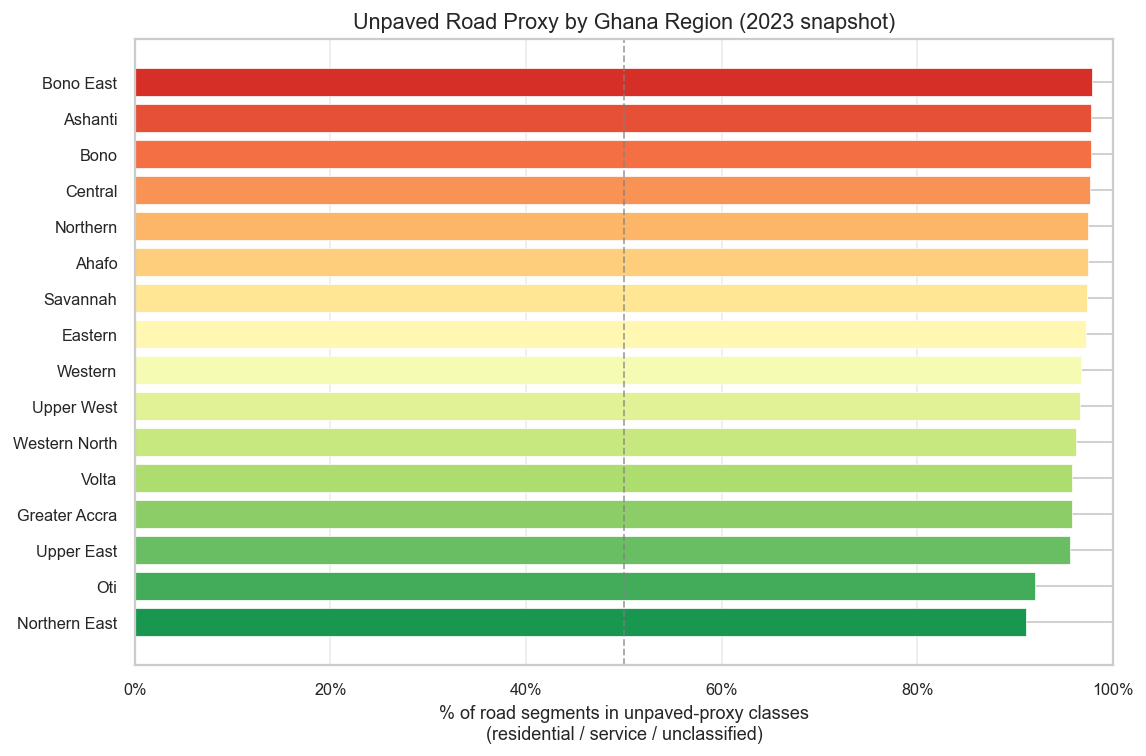

In [22]:
# ── Figure 11: Unpaved fraction by region ────────────────────────────────────
# Proxy: residential + service + unclassified = typically unpaved/informal
UNPAVED_PROXY = ["residential", "service", "unclassified"]

region_cls = (
    df_reg.dropna(subset=["region"])
    .groupby(["region", "fclass"])["osm_id"]
    .nunique()
    .reset_index(name="road_count")
)

# Total roads per region
region_total = region_cls.groupby("region")["road_count"].sum().rename("total")

# Unpaved proxy count
region_unpaved = (
    region_cls[region_cls["fclass"].isin(UNPAVED_PROXY)]
    .groupby("region")["road_count"]
    .sum()
    .rename("unpaved")
)

region_comp = pd.concat([region_total, region_unpaved], axis=1).fillna(0)
region_comp["unpaved_pct"] = 100 * region_comp["unpaved"] / region_comp["total"]
region_comp = region_comp.sort_values("unpaved_pct", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(region_comp))
)
ax.barh(
    region_comp.index, region_comp["unpaved_pct"],
    color=colors, edgecolor="white", linewidth=0.4,
)
ax.axvline(50, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("% of road segments in unpaved-proxy classes\n"
              "(residential / service / unclassified)")
ax.set_title("Unpaved Road Proxy by Ghana Region (2023 snapshot)")
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", alpha=0.35)
plt.tight_layout()
plt.show()


In [23]:
# Annual NDVI mean by region (all years)
# Merge region lookup onto full df (not just 2023)
df_all_reg = df.merge(
    lookup[["osm_id", "region"]].drop_duplicates("osm_id"),
    on="osm_id", how="left",
)

region_year_ndvi = (
    df_all_reg.dropna(subset=["region"])
    .groupby(["region", "year"])["NDVI"]
    .mean()
    .reset_index()
)

# Keep top 10 regions by road count for legibility
top10_regions = (
    df_all_reg.dropna(subset=["region"])
    .groupby("region")["osm_id"]
    .nunique()
    .nlargest(10)
    .index.tolist()
)
print("Top 10 regions by road count:", top10_regions)


Top 10 regions by road count: ['Greater Accra', 'Ashanti', 'Eastern', 'Central', 'Northern', 'Western', 'Volta', 'Bono', 'Bono East', 'Upper West']


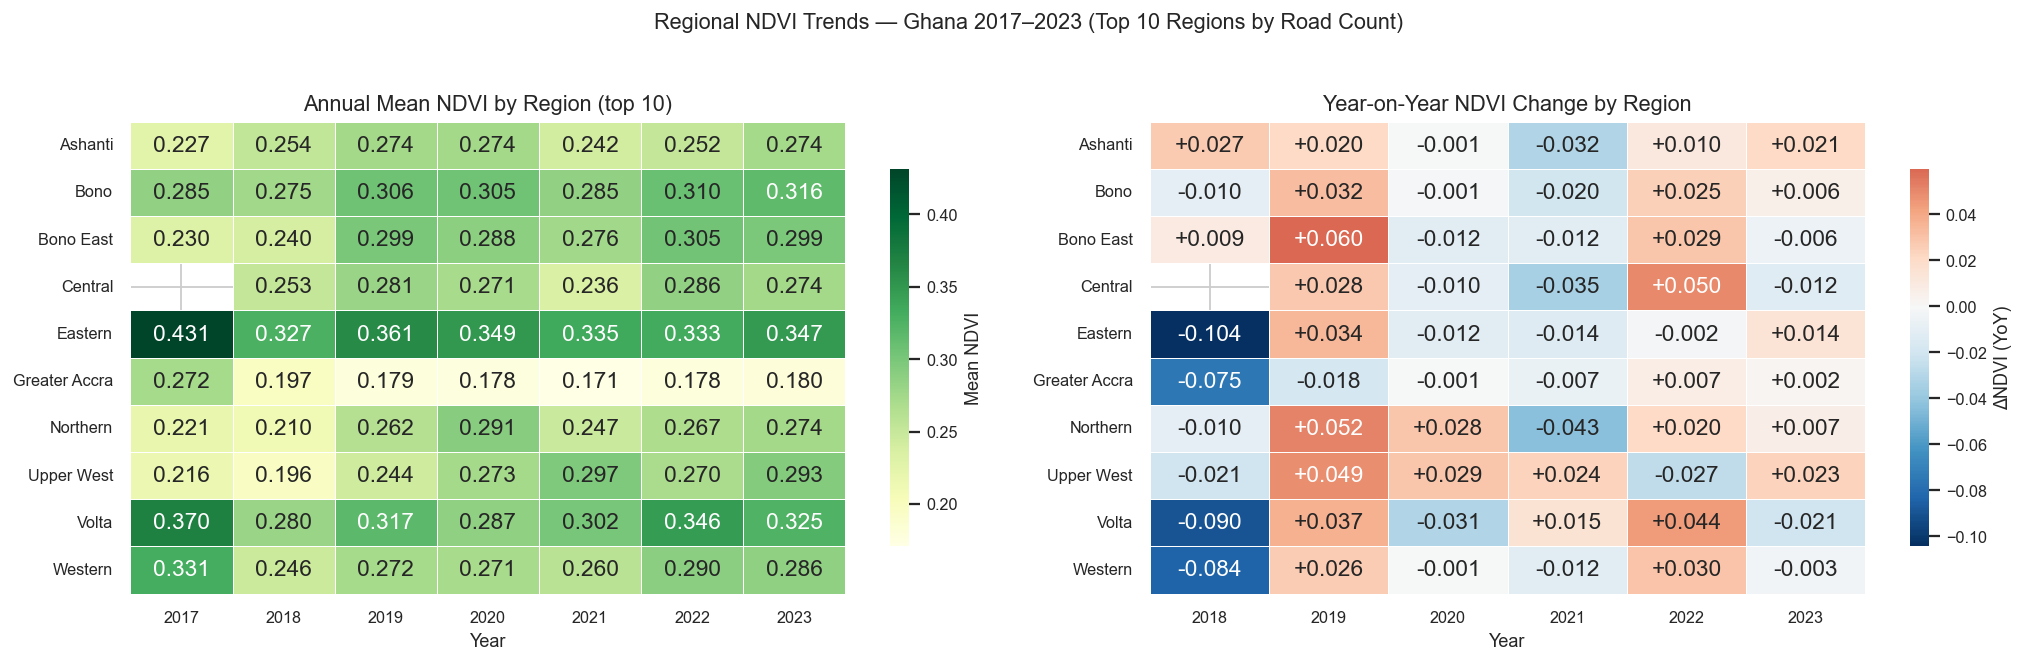

In [24]:
# ── Figure 12: NDVI YoY heatmap by region (top 10) ───────────────────────────
pivot_region = (
    region_year_ndvi[region_year_ndvi["region"].isin(top10_regions)]
    .pivot(index="region", columns="year", values="NDVI")
)

# Compute YoY deltas (column-wise diff)
pivot_yoy = pivot_region.diff(axis=1).iloc[:, 1:]  # drop first year (NaN)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: absolute NDVI
sns.heatmap(
    pivot_region, annot=True, fmt=".3f",
    cmap="YlGn", linewidths=0.5, ax=axes[0],
    cbar_kws={"label": "Mean NDVI", "shrink": 0.8},
)
axes[0].set_title("Annual Mean NDVI by Region (top 10)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("")

# Right: YoY delta
sns.heatmap(
    pivot_yoy, annot=True, fmt="+.3f",
    cmap="RdBu_r", center=0, linewidths=0.5, ax=axes[1],
    cbar_kws={"label": "ΔNDVI (YoY)", "shrink": 0.8},
)
axes[1].set_title("Year-on-Year NDVI Change by Region")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("")

plt.suptitle("Regional NDVI Trends — Ghana 2017–2023 (Top 10 Regions by Road Count)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## Summary & Key Findings

### Spectral Characterisation (Part 2)
- **Unclassified** roads have markedly higher NDVI and lower BSI than other
  classes, consistent with more vegetated rural settings.
- **Service** roads show the lowest NDVI and highest BSI, suggesting more
  urban / impervious surroundings.
- NDBI and NDWI are mirror images by construction (same band ratio, inverted
  sign); only one needs to enter the model.

### Seasonal Patterns (Part 3)
- NDVI peaks in Q2–Q3 (Ghana's main rainy season, Apr–Sep) and dips in Q1
  (dry harmattan season).
- BSI follows the inverse pattern — peaking in Q1 (dry, bare soil exposed).
- **Seasonal amplitude is highest for unclassified and tertiary roads**,
  implying more vegetation-sensitive surroundings; trunk/primary are flatter.

### Year-on-Year Trends (Part 4)
- A systematic NDVI dip in 2018 affects all classes; likely a combination
  of below-average rainfall and satellite compositing artefacts.
- 2019 shows a BSI drop across all classes, possibly linked to enhanced
  vegetation cover from the 2018–2019 wet season.
- No monotonic multi-year degradation trend is visible at the class level —
  consistent with the classification task being spatially rather than
  temporally structured.

### Road-Level Features (Part 5)
- Approximately 30–40 % of roads show a temporal degradation signal
  (NDVI↓ & BSI↑ over 2017–2023) depending on class.
- Service and trunk roads have the highest flagged proportions — consistent
  with high traffic and urban heat island effects.

### Regional Analysis (Part 6)
- Greater Accra and Ashanti regions have the lowest unpaved-proxy fractions,
  reflecting their urban density and formal road networks.
- Northern regions have higher unpaved fractions, corroborating NIRTIMS
  findings of more poor/fair road conditions there.
